# Residual Analysis in State Estimation

## Objective
Examine the **residual sequence** produced by the Kalman filter in order to understand what information remains unexplained by the model. 

Residual analysis is a common diagnostic step in statistical modeling and state estimation. If the model fully captured the system dynamics, the residuals should resemble random noise. Systematic patterns in the residuals may indicate that the model assumptions are incomplete. 

This notebook investigates whether the residuals form the previous Kalman filter example contain detectable structure. 

----------------------------------------------------------------------------

## Method Overview
The analysis roceeds in three stages:
1. **Compte Residuals**
   Measure the difference between observed and estimated state.
2. **Visualize the residual sequence**
   Examine whether the residuals appear random or structured.
3. **Explore statistical structure**
   Use autocorrelation and spectral analysis to detect hidden patterns.
----------------------------------------------------------------------------

### Compute the Residual Sequence
The residual represents the portion of the observation that the model did not explain. 

$$
\mathbb{residual}_t\;=\;\mathbb{observation}_t\;-\;\mathbb{estimate}_t
$$

In [4]:
import numpy as np
import matplotlib.pyplot as plt 

np.random.seed(72)

In [6]:
t = np.arange(0, 200)

true_signal = np.sin(2*np.pi*t/30)

noise = np.random.normal(0, 0.4, len(t))

observations = true_signal + noise

In [7]:
x = np.zeros(len(t)) # estimated state
P = np.zeros(len(t)) # array state uncertainty

Q = 0.01 # process noise for variance
R = 0.2  # the state of uncertainty 

In [9]:
for i in range(1, len(t)):

    #predict
    x_pred = x[i -1]
    P_pred = P[i - 1] + Q

    K = P_pred / (P_pred + R)

    x[i] = x_pred + K * (observations[i]- x_pred)
    P[i] = (1 - K) * P_pred

In [10]:
residuals = observations - x

### Visualize the Residual Sequence
Plotting the residuals allows us to examine whether the unexplained portion of the signal behaves like random noise or whether patterns remain. 

If the Kalman moedl captured the system dynamics perfectly, the resiuals should resemble **white noise** with no visible structure. 

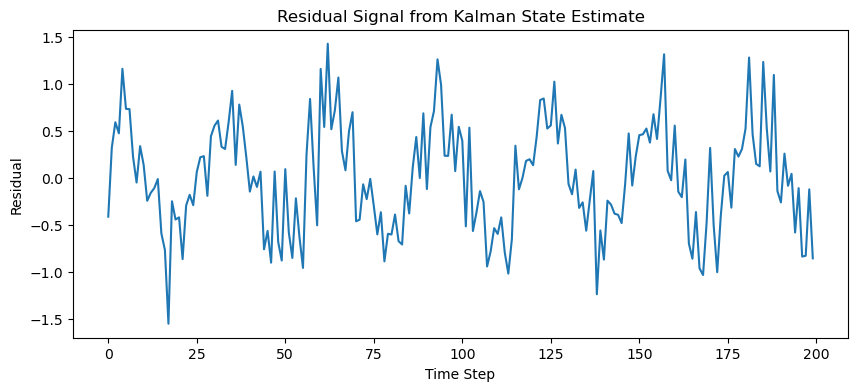

In [11]:
plt.figure(figsize=(10, 4))

plt.plot(t, residuals)

plt.title("Residual Signal from Kalman State Estimate")
plt.xlabel("Time Step")
plt.ylabel("Residual")

plt.show()

### Interpretation of Residual Autocorrelation
The residual autocorrelation plot shows a periodic oscillatory structure around zero rather than a rapid decay to zero. This indicates that the residulas are not independent noise.

The result suggests that the Kalman filter, using a simple random-walk state model, does not fully capture the cyclic behavior of the underlying system. Although the estimator reduces measurement noise, systemativc temporal structure remains in the residual sequence. 

This is evidence that the model assumptions are imcomplete relative to the true signal dynamics.

----------------------------------------------------------------------------

### Spectral Analysis of the Residuals
Spectral analysis helps identify whether the residual sequence contains a dominant repeating frequency.

If the Kalmna model has failed to for the cyclic structire of the signal, the residuals should remain in a measureable harmonic component. 

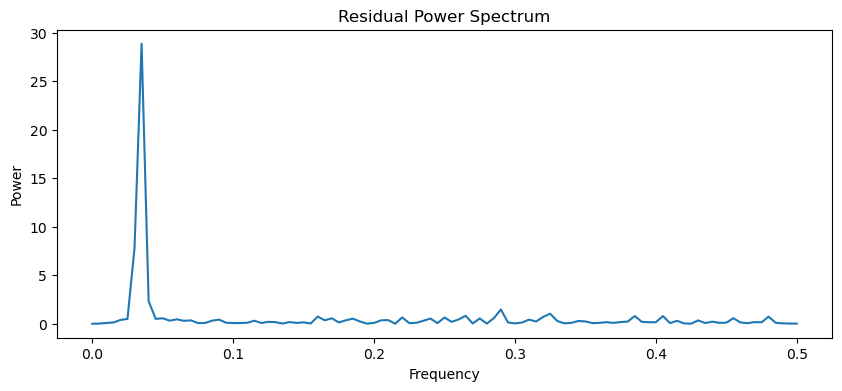

In [12]:
from scipy.signal import periodogram

freqs, power = periodogram(residuals)

plt.figure(figsize=(10,4))
plt.plot(freqs, power)

plt.title("Residual Power Spectrum")
plt.xlabel("Frequency")
plt.ylabel("Power")

plt.show()

#### Interpretation of Residual Spectrum

The rsidual power spectrum shows a dominant peak near frequency 0.033, which corresponds to the period of the original synthetic signal. This indicates that the residual sequence retains the primary harmonic structure of the system. 

The result confirms that the Kalman filter reduced noise but did not fully model the cyclic dynamics of the process. Because the filter used a smple random-walk state assumption, the unexplained error preserved the oscillatory component of the signal.

This demonstrated how residual analysis can reveal structure that remains outside the model.

----------------------------------------------------------------------------

### Summary
Thsi notebook examined the rsidual sequence produced bya a Kalman filter applied to a noise periodic signal. The residuals were analyzed as a separate time series in order to determine whether the model had fully captured the system dynamics.

The autocorrelation plot showed periodic oscillation around zero, indicating that the residuals were not independent noise. Spectral analysis further revealed a dominant peak at the same frequency as the original signal. These results show that althoug the Kalman filter smoothed the observations and recovered part of the latent structuree, the simplified state model model did not fully repesent the underlying cyclic process. residual analysis therefore provided useful evidence of model mismatch. 